In [1]:
print(5)

5


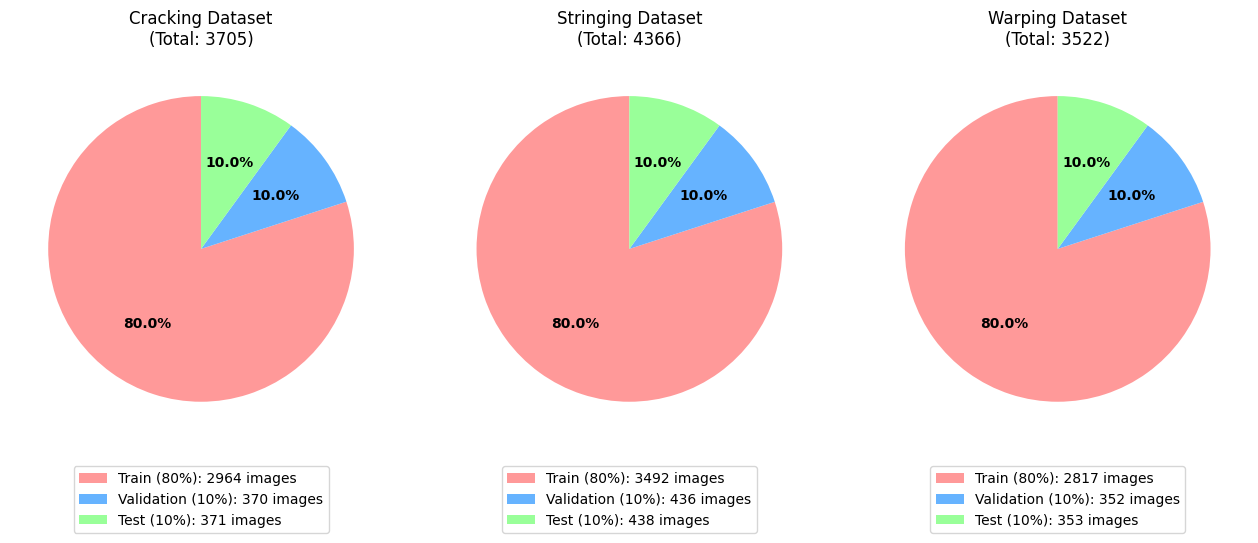

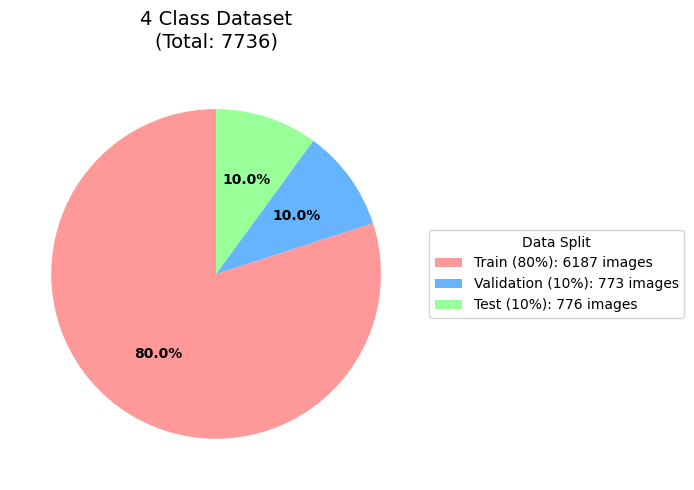

In [10]:
import os
import matplotlib.pyplot as plt

# Helper function to count image files in a directory and its subdirectories
def count_images(directory):
    count = 0
    if os.path.exists(directory):
        for root, dirs, files in os.walk(directory):
            count += len([f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    return count

base_dir = "/home/feriel/PFE/Defect-Detection/data"

# 1. Cracking Split
cracking_total = count_images(os.path.join(base_dir, "Cracking")) + count_images(os.path.join(base_dir, "No_Cracking"))
cracking_train = int(cracking_total * 0.8)
cracking_val = int(cracking_total * 0.1)
cracking_test = cracking_total - cracking_train - cracking_val

# 2. Stringing Split
stringing_total = count_images(os.path.join(base_dir, "Stringing")) + count_images(os.path.join(base_dir, "No_Stringing"))
stringing_train = int(stringing_total * 0.8)
stringing_val = int(stringing_total * 0.1)
stringing_test = stringing_total - stringing_train - stringing_val

# 3. Warping Split
warping_total = count_images(os.path.join(base_dir, "Warping")) + count_images(os.path.join(base_dir, "No_Warping"))
warping_train = int(warping_total * 0.8)
warping_val = int(warping_total * 0.1)
warping_test = warping_total - warping_train - warping_val

# 4. Splitted data (already divided)
split_base = "/home/feriel/PFE/Defect-Detection/splitted data"
split_train = count_images(os.path.join(split_base, "train"))
split_val = count_images(os.path.join(split_base, "val"))
split_test = count_images(os.path.join(split_base, "test"))

# --- Plotting Configuration ---
labels = ['Train (80%)', 'Validation (10%)', 'Test (10%)']
colors = ['#ff9999', '#66b3ff', '#99ff99']

# =====================================================================
# FIGURE 1: The 3 Defect Datasets
# =====================================================================
defect_datasets = [
    ("Cracking Dataset", [cracking_train, cracking_val, cracking_test]),
    ("Stringing Dataset", [stringing_train, stringing_val, stringing_test]),
    ("Warping Dataset", [warping_train, warping_val, warping_test])
]

fig1, axs1 = plt.subplots(1, 3, figsize=(13, 5))
fig1.subplots_adjust(wspace=0.01)

for i, (title, counts) in enumerate(defect_datasets):
    total = sum(counts)
    if total == 0:
        axs1[i].text(0.5, 0.5, 'No Images Found', ha='center', va='center')
        axs1[i].set_title(title)
        axs1[i].axis('off')
        continue
        
    legend_labels = [f"{label}: {count} images" for label, count in zip(labels, counts)]
    
    wedges, texts, autotexts = axs1[i].pie(
        counts, 
        colors=colors, 
        autopct='%1.1f%%', 
        startangle=90, 
        textprops=dict(color="black", weight="bold")
    )
    
    axs1[i].set_title(f"{title}\n(Total: {total})", fontsize=12, pad=10)
    # Place legend below each pie chart to save horizontal space
    axs1[i].legend(wedges, legend_labels, loc="upper center", bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.show()

# =====================================================================
# FIGURE 2: The Overall Splitted Data
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(7, 5))

title_split = "4 Class Dataset"
counts_split = [split_train, split_val, split_test]
total_split = sum(counts_split)

if total_split == 0:
    ax2.text(0.5, 0.5, 'No Images Found', ha='center', va='center')
    ax2.set_title(title_split)
    ax2.axis('off')
else:
    legend_labels_split = [f"{label}: {count} images" for label, count in zip(labels, counts_split)]
    
    wedges_split, texts_split, autotexts_split = ax2.pie(
        counts_split, 
        colors=colors, 
        autopct='%1.1f%%', 
        startangle=90, 
        textprops=dict(color="black", weight="bold")
    )
    
    ax2.set_title(f"{title_split}\n(Total: {total_split})", fontsize=14, pad=15)
    # Place legend on the side for this single chart
    ax2.legend(wedges_split, legend_labels_split, title="Data Split", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

plt.tight_layout()
plt.show()


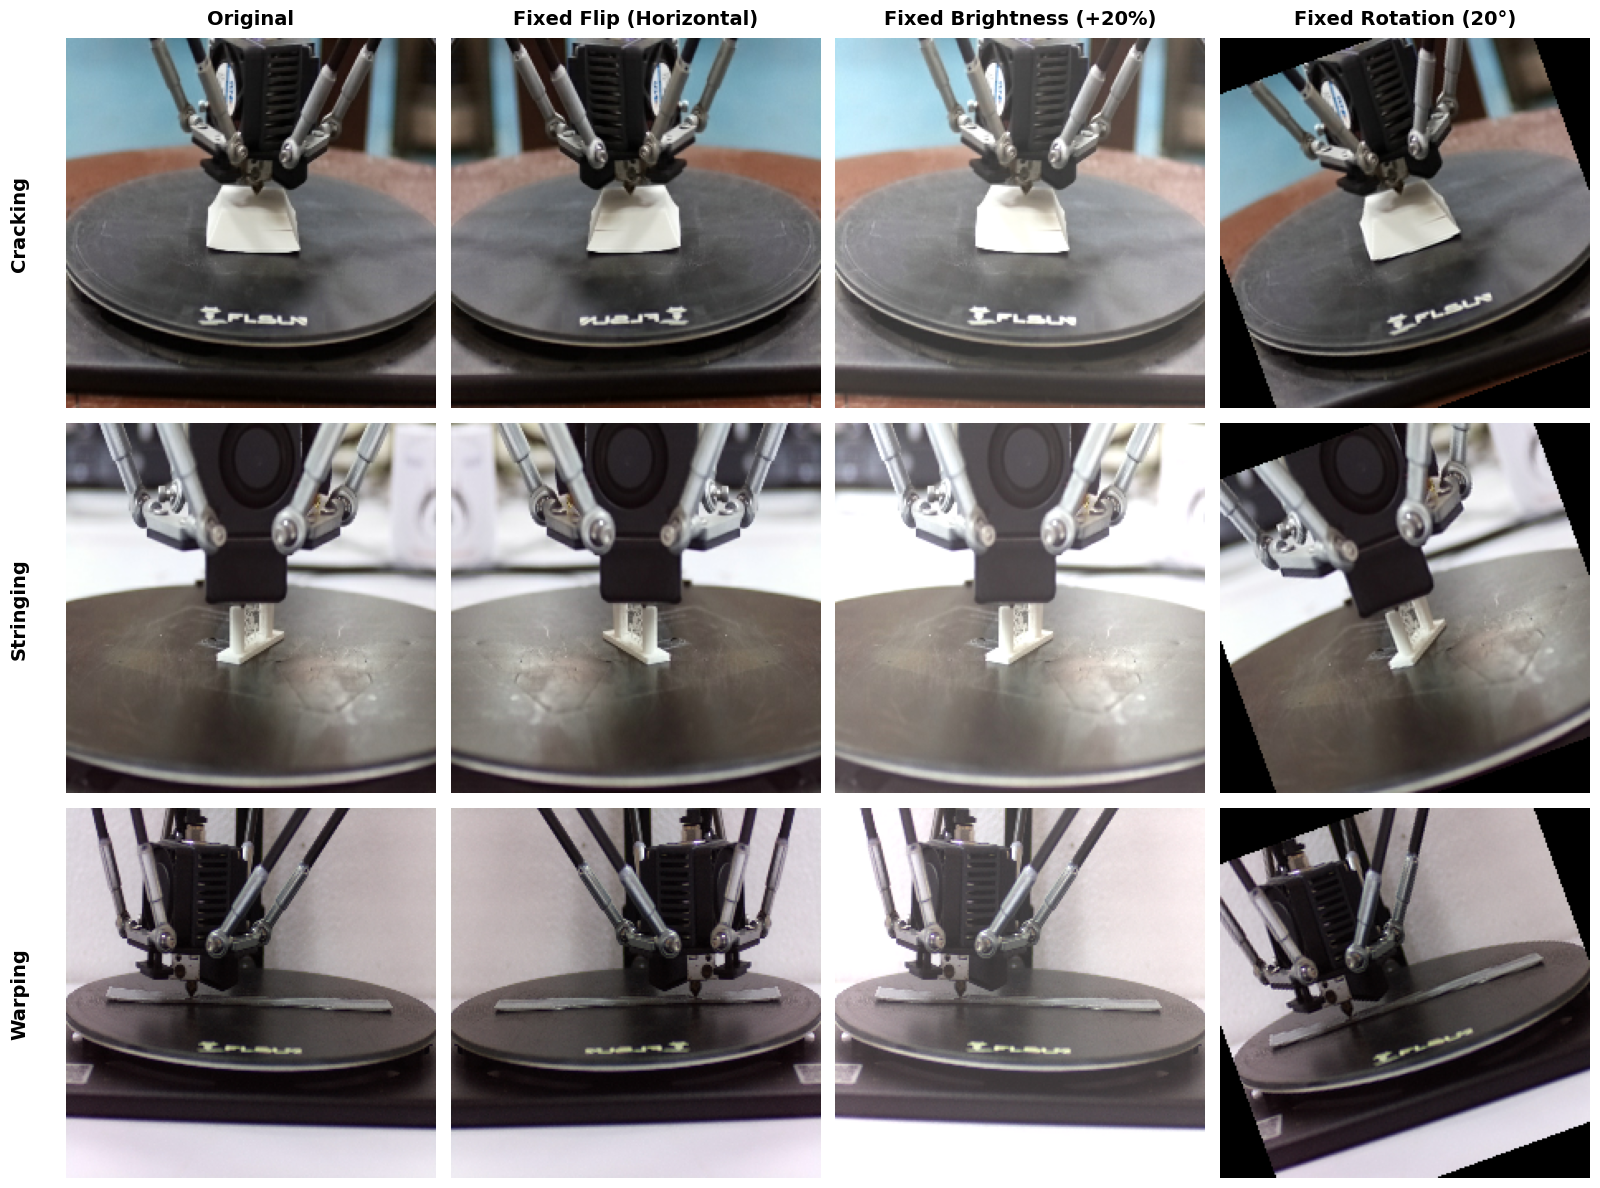

In [21]:
import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import scipy.ndimage

# Define the folders for the three defect classes
sample_folders = [
    ("Cracking", "/home/feriel/PFE/Defect-Detection/data/Cracking"),
    ("Stringing", "/home/feriel/PFE/Defect-Detection/data/Stringing"),
    ("Warping", "/home/feriel/PFE/Defect-Detection/data/Warping")
]

SEED        = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE    = (224, 224)

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img

# Set up a 3x4 grid for plotting
fig, axs = plt.subplots(3, 4, figsize=(16, 12))

# Updated column titles to reflect your specific pipeline bounds
cols = ["Original", "Fixed Flip (Horizontal)", "Fixed Brightness (+20%)", "Fixed Rotation (20°)"]
for ax, col in zip(axs[0], cols):
    ax.set_title(col, fontsize=14, pad=10, fontweight="bold")

for i, (class_name, folder_path) in enumerate(sample_folders):
    # 1. Select a random .jpg image from the class folder
    images = [f for f in os.listdir(folder_path) if f.endswith(".jpg")]
    random_img_name = random.choice(images)
    img_path = os.path.join(folder_path, random_img_name)
    
    # 2. Load and preprocess the image
    original_img = load_and_preprocess(img_path)
    
    # 3. Plot the ORIGINAL image
    axs[i, 0].imshow(original_img)
    axs[i, 0].axis("off")
    axs[i, 0].text(-0.1, 0.5, class_name, transform=axs[i, 0].transAxes, 
                   fontsize=14, fontweight='bold', va='center', ha='right', rotation=90)
    
    # 4. Plot FIXED FLIP (Always horizontally flips the image)
    img_flipped = tf.image.flip_left_right(original_img)
    axs[i, 1].imshow(img_flipped)
    axs[i, 1].axis("off")
    
    # 5. Plot FIXED BRIGHTNESS (Always increases brightness by exactly +20% / 0.2 delta)
    img_bright = tf.image.adjust_brightness(original_img, delta=0.2)
    img_bright = tf.clip_by_value(img_bright, 0.0, 1.0) # Ensure pixel values stay valid
    axs[i, 2].imshow(img_bright)
    axs[i, 2].axis("off")

    # 6. Plot FIXED ROTATION (Always rotates exactly 20 degrees counter-clockwise)
    # Convert TF tensor to numpy for scipy, rotate, and clip values to valid image range
    img_rotated = scipy.ndimage.rotate(original_img.numpy(), angle=20, reshape=False)
    img_rotated = np.clip(img_rotated, 0.0, 1.0)
    axs[i, 3].imshow(img_rotated)
    axs[i, 3].axis("off")

plt.tight_layout()
plt.show()
